In [1]:
!pip install prophet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
0
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
df1 = pd.read_csv("Year_2009_2010_Cleaned.csv")
df2 = pd.read_csv("Year_2010_2011_Cleaned.csv")

df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(804083, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,SalesAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Regular,Online,UPI,High,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Regular,Online,UPI,Low,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Premium,Offline,Card,Medium,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,New,Retail,Cash,Low,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Regular,Online,Net Banking,High,30.0


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Quantity"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["ds", "y"]

daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

daily_sales.head()

,ds,y
0,2009-12-01,24403
1,2009-12-02,29751
2,2009-12-03,48032
3,2009-12-04,20057
4,2009-12-05,5119


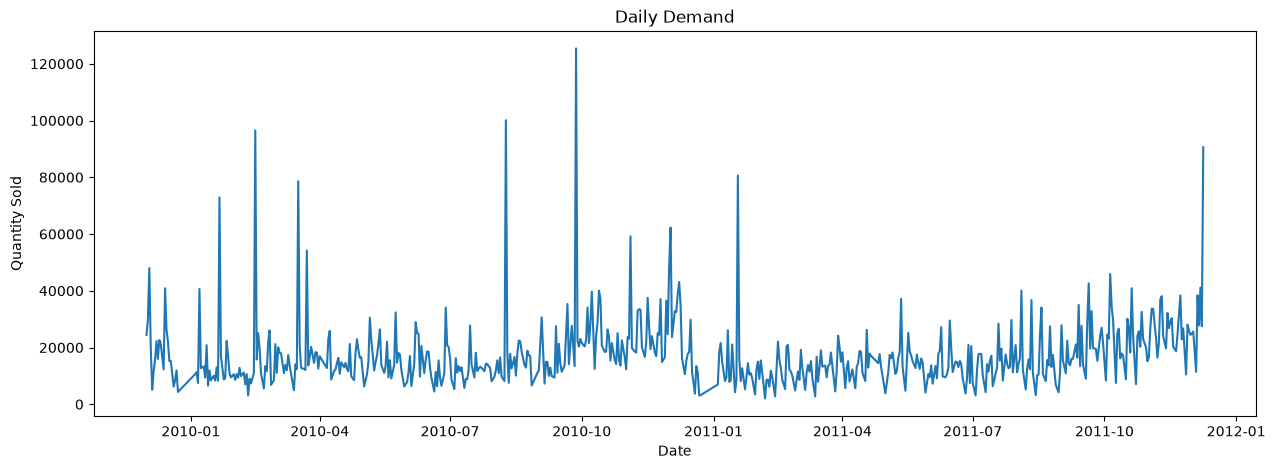

In [5]:
plt.figure(figsize=(15,5))
plt.plot(daily_sales["ds"], daily_sales["y"])
plt.title("Daily Demand")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

In [6]:
train = daily_sales[:-30]
test = daily_sales[-30:]

print(train.shape)
print(test.shape)

(574, 2)
(30, 2)


In [7]:
model = Prophet()

model.fit(train)

22:23:10 - cmdstanpy - INFO - Chain [1] start processing
22:23:11 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,14309.627236,3964.844845,31534.971734,14309.627236,14309.627236,3565.115138,3565.115138,3565.115138,3565.115138,3565.115138,3565.115138,0.0,0.0,0.0,17874.742374
1,2009-12-02,14317.285482,3339.149685,31256.936138,14317.285482,14317.285482,2498.518826,2498.518826,2498.518826,2498.518826,2498.518826,2498.518826,0.0,0.0,0.0,16815.804308
2,2009-12-03,14324.943729,6233.864238,34838.350076,14324.943729,14324.943729,6395.923100,6395.923100,6395.923100,6395.923100,6395.923100,6395.923100,0.0,0.0,0.0,20720.866829
3,2009-12-04,14332.601975,-601.480147,27400.738438,14332.601975,14332.601975,-698.984406,-698.984406,-698.984406,-698.984406,-698.984406,-698.984406,0.0,0.0,0.0,13633.617569
4,2009-12-05,14340.260221,-9418.228975,17304.151868,14340.260221,14340.260221,-10419.301066,-10419.301066,-10419.301066,-10419.301066,-10419.301066,-10419.301066,0.0,0.0,0.0,3920.959155


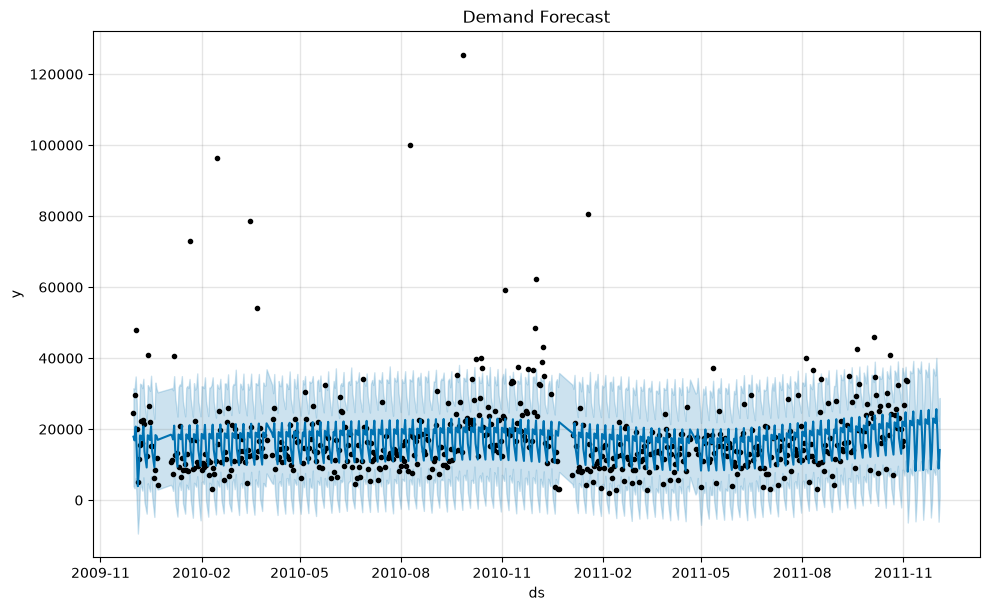

In [9]:
fig = model.plot(forecast)
plt.title("Demand Forecast")
plt.show()

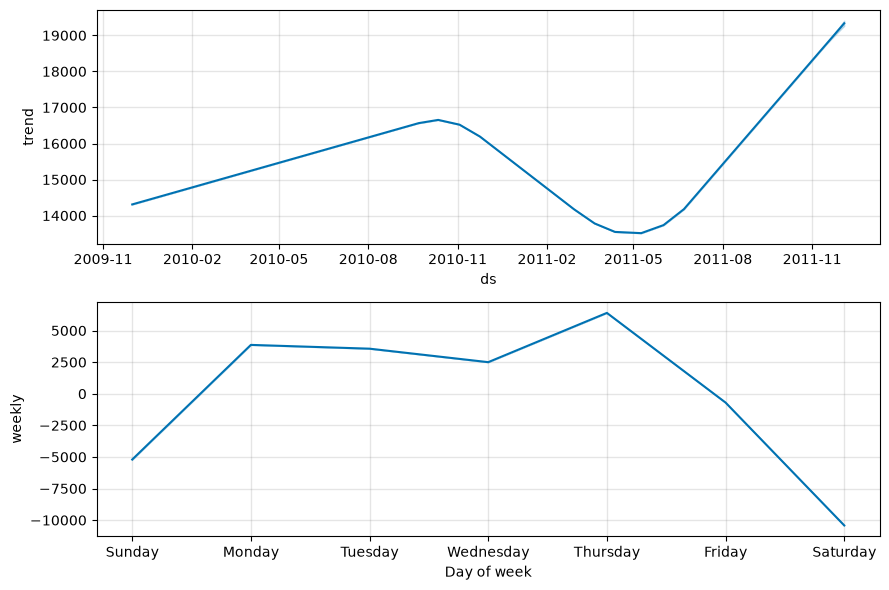

In [10]:
fig2 = model.plot_components(forecast)
plt.show()

In [11]:
pred = forecast[["ds", "yhat"]].tail(30)

comparison = test.merge(pred, on="ds")

comparison.head()

,ds,y,yhat
0,2011-11-06,23288,13253.978288
1,2011-11-07,16443,22356.290964
2,2011-11-08,21658,22087.758675
3,2011-11-09,37016,21052.411106
4,2011-11-10,38098,24981.064124


In [12]:
mae = mean_absolute_error(comparison["y"], comparison["yhat"])
rmse = np.sqrt(mean_squared_error(comparison["y"], comparison["yhat"]))

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 6225.63
RMSE: 7561.44


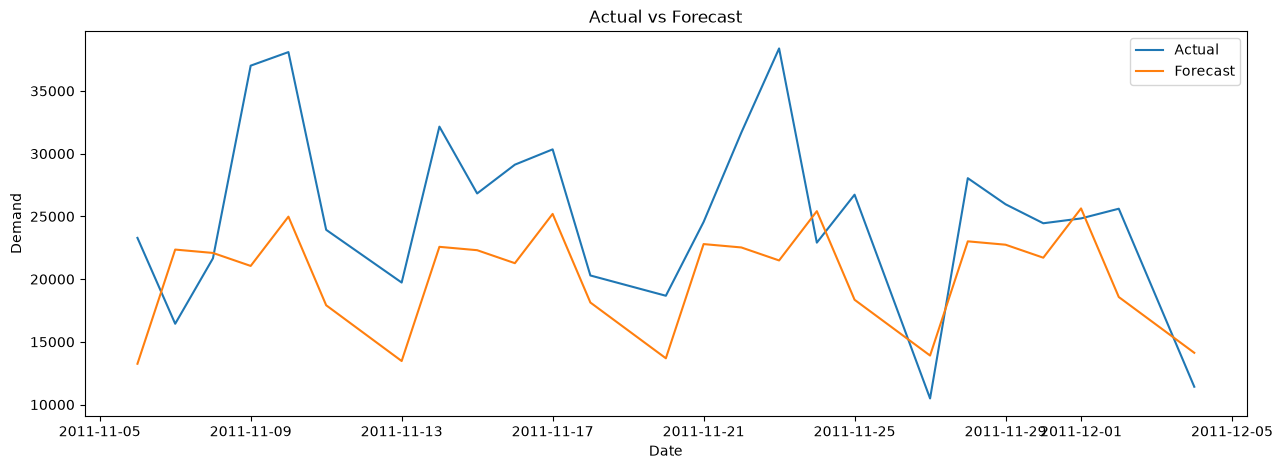

In [13]:
plt.figure(figsize=(15,5))

plt.plot(comparison["ds"], comparison["y"], label="Actual")
plt.plot(comparison["ds"], comparison["yhat"], label="Forecast")

plt.legend()
plt.title("Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

In [14]:
forecast.to_csv("prophet_forecast.csv", index=False)

print("Forecast saved successfully.")

Forecast saved successfully.
